In [ ]:
import os
import platform
import h5py
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import subprocess
from tqdm.notebook import tqdm
import imageio_ffmpeg
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler

# --- 1. CONFIGURATION & PATHS ---
MODEL_NUMBER = 2
load_dotenv()
current_os = platform.system()
base_dir = os.getenv("BASE_DIR_WIN") if current_os == "Windows" else os.getenv("BASE_DIR_LIN")

derived_dir = os.path.join(base_dir, "output/DNS_CC_Re150_Mazi")
model_dir = os.path.join(derived_dir, f"Model_{MODEL_NUMBER}")
os.makedirs(model_dir, exist_ok=True)

data_path = os.path.join(derived_dir, "lstm_ready_data.h5")
grid_h5 = os.path.join(derived_dir, "dns_regular_0.02D_2d.h5")
ckpt_path = os.path.join(model_dir, "latest_checkpoint.pt")
video_out = os.path.join(model_dir, f"vorticity_recon_M{MODEL_NUMBER}.mp4")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()

# --- 2. ARCHITECTURE DEFINITION ---
class SupersamplingBiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, n_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, n_layers, 
                            batch_first=True, dropout=0.1, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(), 
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# --- 3. LOAD DATA & MODEL ---
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
scaler_ss, scaler_ff = checkpoint['scaler_ss'], checkpoint['scaler_ff']
hidden_dim, seq_len = checkpoint['config']['hidden_dim'], checkpoint['config']['seq_len']
half_len = seq_len // 2

with h5py.File(data_path, 'r') as f:
    a_ff_test, a_ss_test = f['test/a_ff'][:], f['test/a_ss'][:]
    test_time, phi_ff, mean_ff = f['test/time'][:], f['phi_ff'][:], f['mean_ff'][:]

with h5py.File(grid_h5, 'r') as f_grid:
    x_coords, y_coords = f_grid['x'][:], f_grid['y'][:]

model = SupersamplingBiLSTM(a_ss_test.shape[1], hidden_dim, a_ff_test.shape[1]).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

# --- 4. BATCHED INFERENCE ---
a_ss_norm = scaler_ss.transform(a_ss_test)
indices = np.arange(half_len, len(a_ss_test) - half_len)
a_ff_pred_norm = []

with torch.no_grad():
    for i in tqdm(range(0, len(indices), 1024), desc="Inference"):
        batch_idx = indices[i:i+1024]
        x_batch = [a_ss_norm[idx - half_len : idx + half_len, :] for idx in batch_idx]
        a_ff_pred_norm.append(model(torch.FloatTensor(np.array(x_batch)).to(device)).cpu().numpy())

a_ff_pred = scaler_ff.inverse_transform(np.vstack(a_ff_pred_norm))
a_ff_true, time_aligned = a_ff_test[indices], test_time[indices]

# --- 5. PHYSICAL RECONSTRUCTION ---
n_points = mean_ff.shape[0] // 2
Nx, Ny = len(x_coords), len(y_coords)
dx, dy = x_coords[1] - x_coords[0], y_coords[1] - y_coords[0]

def get_fields(a_coeffs):
    ux = (mean_ff[:n_points] + a_coeffs @ phi_ff[:, :n_points]).reshape(-1, Ny, Nx)
    uy = (mean_ff[n_points:] + a_coeffs @ phi_ff[:, n_points:]).reshape(-1, Ny, Nx)
    vort = np.gradient(uy, dx, axis=2) - np.gradient(ux, dy, axis=1)
    return ux, uy, vort

ux_p, uy_p, vort_p = get_fields(a_ff_pred)
ux_t, uy_t, vort_t = get_fields(a_ff_true)

# --- 6. SEPARATE STATISTICAL PLOTS ---
print("Generating statistical error plots...")
stats = {
    "u_mean": (np.mean(ux_p, 0) - np.mean(ux_t, 0), r"Mean $u$ Error"),
    "v_mean": (np.mean(uy_p, 0) - np.mean(uy_t, 0), r"Mean $v$ Error"),
    "uu_stress": (np.mean((ux_p - np.mean(ux_p, 0))**2, 0) - np.mean((ux_t - np.mean(ux_t, 0))**2, 0), r"$\overline{u'u'}$ Error"),
    "vv_stress": (np.mean((uy_p - np.mean(uy_p, 0))**2, 0) - np.mean((uy_t - np.mean(uy_t, 0))**2, 0), r"$\overline{v'v'}$ Error"),
    "uv_stress": (np.mean((ux_p - np.mean(ux_p, 0))*(uy_p - np.mean(uy_p, 0)), 0) - 
                  np.mean((ux_t - np.mean(ux_t, 0))*(uy_t - np.mean(uy_t, 0)), 0), r"$\overline{u'v'}$ Error")
}

extent = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]
for name, (data, title) in stats.items():
    plt.figure(figsize=(8, 3))
    vlim = np.max(np.abs(data))
    im = plt.imshow(data, extent=extent, origin='lower', cmap='bwr', vmin=-vlim, vmax=vlim)
    plt.gca().add_patch(plt.Circle((0,0), 0.5, color='gray'))
    plt.title(title)
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig(os.path.join(model_dir, f"stat_{name}.png"), dpi=200)
    plt.close()

# --- 7. VIDEO RENDERING ---
v_max = np.percentile(np.abs(vort_t), 99)
error_map = (np.abs(vort_p - vort_t) / v_max) * 100
err_vmax = max(np.percentile(error_map, 99), 0.1)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 11), dpi=100)
ims = []
for ax, title, cmap, vmin, vmax in zip([ax1, ax2, ax3], 
    [f'Bi-LSTM (M{MODEL_NUMBER}) Vorticity', 'Ground Truth DNS', 'Normalized Absolute Error (%)'],
    ['RdBu_r', 'RdBu_r', 'inferno'], [-v_max, -v_max, 0], [v_max, v_max, err_vmax]):
    
    ax.set_title(title)
    ax.add_patch(plt.Circle((0, 0), 0.5, color='gray', zorder=10))
    im = ax.imshow(np.zeros((Ny, Nx)), extent=extent, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, animated=True)
    plt.colorbar(im, ax=ax, pad=0.02, aspect=10)
    ims.append(im)

plt.tight_layout()
fig.canvas.draw()
w, h = fig.canvas.get_width_height()

ffmpeg_cmd = [ffmpeg_exe, '-y', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', f'{w}x{h}',
              '-pix_fmt', 'rgba', '-r', '30', '-i', '-', '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
              '-preset', 'fast', '-crf', '18', video_out]
process = subprocess.Popen(ffmpeg_cmd, stdin=subprocess.PIPE)

for t in tqdm(range(len(time_aligned)), desc="Rendering Video"):
    ims[0].set_array(vort_p[t])
    ims[1].set_array(vort_t[t])
    ims[2].set_array(error_map[t])
    fig.suptitle(f"Model {MODEL_NUMBER} | Time: {time_aligned[t]:.3f}s", fontsize=16)
    fig.canvas.draw()
    process.stdin.write(fig.canvas.buffer_rgba())

process.stdin.close()
process.wait()
plt.close(fig)
print(f"Complete. Video saved to {video_out}")

Inference:   0%|          | 0/4 [00:00<?, ?it/s]

Generating statistical error plots...


ffmpeg version 7.0.2-static https://johnvansickle.com/ffmpeg/  Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (Debian 8.3.0-6)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-debug --disable-ffplay --disable-indev=sndio --disable-outdev=sndio --cc=gcc --enable-fontconfig --enable-frei0r --enable-gnutls --enable-gmp --enable-libgme --enable-gray --enable-libaom --enable-libfribidi --enable-libass --enable-libvmaf --enable-libfreetype --enable-libmp3lame --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-librubberband --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libvorbis --enable-libopus --enable-libtheora --enable-libvidstab --enable-libvo-amrwbenc --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libdav1d --enable-libxvid --enable-libzvbi --enable-libzimg
  libavutil      59.  8.100 / 59.  8.100
  libavcodec     61.  3.100 / 61.  3.100
  libavformat   

Rendering Video:   0%|          | 0/4000 [00:00<?, ?it/s]

Input #0, rawvideo, from 'fd:':
  Duration: N/A, start: 0.000000, bitrate: 1372800 kb/s
  Stream #0:0: Video: rawvideo (RGBA / 0x41424752), rgba, 1300x1100, 1372800 kb/s, 30 tbr, 30 tbn
Stream mapping:
  Stream #0:0 -> #0:0 (rawvideo (native) -> h264 (libx264))
[libx264 @ 0x1c84cb40] using cpu capabilities: MMX2 SSE2Fast SSSE3 SSE4.2 AVX FMA3 BMI2 AVX2 AVX512
[libx264 @ 0x1c84cb40] profile High, level 4.0, 4:2:0, 8-bit
[libx264 @ 0x1c84cb40] 264 - core 164 r3191 4613ac3 - H.264/MPEG-4 AVC codec - Copyleft 2003-2024 - http://www.videolan.org/x264.html - options: cabac=1 ref=2 deblock=1:0:0 analyse=0x3:0x113 me=hex subme=6 psy=1 psy_rd=1.00:0.00 mixed_ref=1 me_range=16 chroma_me=1 trellis=1 8x8dct=1 cqm=0 deadzone=21,11 fast_pskip=1 chroma_qp_offset=-2 threads=34 lookahead_threads=5 sliced_threads=0 nr=0 decimate=1 interlaced=0 bluray_compat=0 constrained_intra=0 bframes=3 b_pyramid=2 b_adapt=1 b_bias=0 direct=1 weightb=1 open_gop=0 weightp=1 keyint=250 keyint_min=25 scenecut=40 intra_re

Complete. Video saved to /media/chris-remote/Projects/ONeill/estimation/output/DNS_CC_Re150_Mazi/Model_2/vorticity_recon_M2.mp4


[out#0/mp4 @ 0x1c84b980] video:41128KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.115797%
frame= 4000 fps= 18 q=-1.0 Lsize=   41176KiB time=00:02:13.26 bitrate=2531.1kbits/s speed=0.609x    
[libx264 @ 0x1c84cb40] frame I:16    Avg QP:13.42  size: 59304
[libx264 @ 0x1c84cb40] frame P:1129  Avg QP:19.34  size: 13582
[libx264 @ 0x1c84cb40] frame B:2855  Avg QP:19.99  size:  9048
[libx264 @ 0x1c84cb40] consecutive B-frames:  1.3%  8.5%  6.5% 83.7%
[libx264 @ 0x1c84cb40] mb I  I16..4: 27.6% 59.2% 13.1%
[libx264 @ 0x1c84cb40] mb P  I16..4:  3.5%  6.9%  0.5%  P16..4: 17.4%  9.1%  3.2%  0.0%  0.0%    skip:59.4%
[libx264 @ 0x1c84cb40] mb B  I16..4:  2.5%  6.4%  0.3%  B16..8: 13.8%  4.5%  0.1%  direct: 5.3%  skip:67.2%  L0:48.1% L1:47.4% BI: 4.5%
[libx264 @ 0x1c84cb40] 8x8 transform intra:67.5% inter:82.3%
[libx264 @ 0x1c84cb40] coded y,uvDC,uvAC intra: 43.5% 78.2% 57.7% inter: 5.0% 9.4% 1.1%
[libx264 @ 0x1c84cb40] i16 v,h,dc,p: 38% 26%  6% 29%
[libx264 

Computing Spatial RMS of the Error (RMSE)...


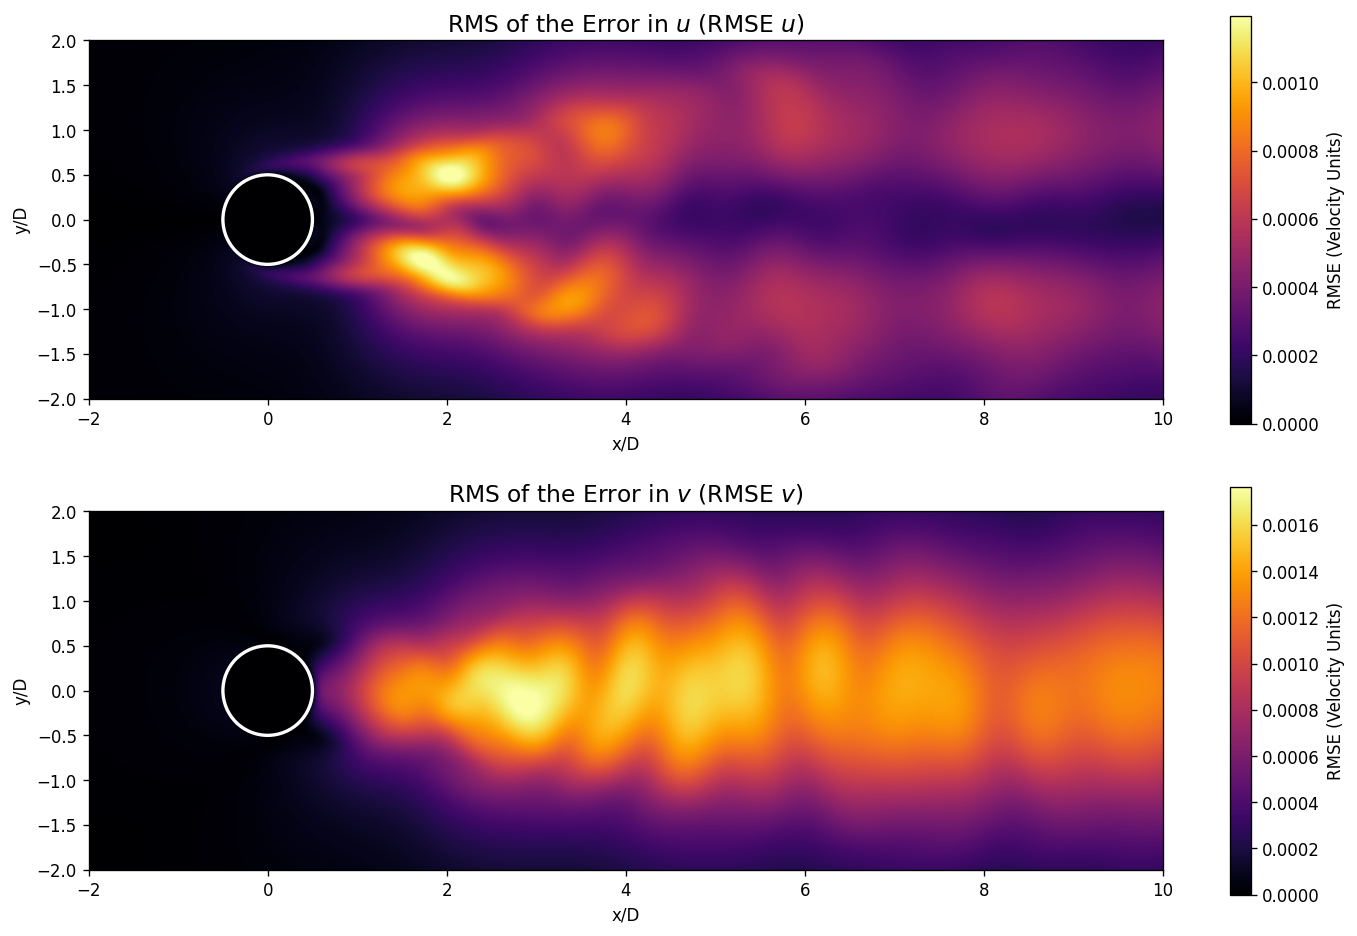

Domain-Averaged RMSE (u): 3.38e-04
Domain-Averaged RMSE (v): 6.25e-04


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# --- 1. Compute RMS of the Error ---
# RMSE(x,y) = sqrt( mean_t( (u_pred(x,y,t) - u_true(x,y,t))^2 ) )
print("Computing Spatial RMS of the Error (RMSE)...")
X_grid, Y_grid = np.meshgrid(x_coords,y_coords)
cylinder_mask = np.power(np.power(X_grid,2.0)+np.power(Y_grid,2.0),0.5)<0.5

rmse_u = np.sqrt(np.mean((ux_p - ux_t)**2, axis=0))
rmse_v = np.sqrt(np.mean((uy_p - uy_t)**2, axis=0))
rmse_u[cylinder_mask]=0.0
rmse_v[cylinder_mask]=0.0


# --- 2. Plotting ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), dpi=120)
extent = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]

def plot_rmse(ax, data, title):
    # Sequential colormap for magnitude-based error
    vmax = np.percentile(data, 99.9) # Robust max to ignore outliers
    im = ax.imshow(data, extent=extent, origin='lower', 
                   cmap='inferno', vmin=0, vmax=vmax)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('x/D')
    ax.set_ylabel('y/D')
    ax.add_patch(Circle((0, 0), 0.5, color='white', fill=False, lw=2, zorder=10))
    fig.colorbar(im, ax=ax, label='RMSE (Velocity Units)')

plot_rmse(axes[0], rmse_u, r"RMS of the Error in $u$ (RMSE $u$)")
plot_rmse(axes[1], rmse_v, r"RMS of the Error in $v$ (RMSE $v$)")

plt.tight_layout()
save_path = os.path.join(model_dir, "spatial_rmse_plots.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Domain-Averaged RMSE (u): {np.mean(rmse_u):.2e}")
print(f"Domain-Averaged RMSE (v): {np.mean(rmse_v):.2e}")